# Bussiness Problem
- Group the similar custemers in order to do better marketing

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')

In [115]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual_Income(k$),Spending_Score(1-100)
0,1,Male,49,123,51
1,2,Female,56,65,86
2,3,Male,66,68,57
3,4,Male,69,22,29
4,5,Male,49,41,78


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CustomerID             200 non-null    int64 
 1   Gender                 200 non-null    object
 2   Age                    200 non-null    int64 
 3   Annual_Income(k$)      200 non-null    int64 
 4   Spending_Score(1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [117]:
df.rename(columns={'Annual_Income(k$)':'Income',
                   'Spending_Score(1-100)':'Score'}, inplace=True)

In [118]:
df.head()

,CustomerID,Gender,Age,Income,Score
0,1,Male,49,123,51
1,2,Female,56,65,86
2,3,Male,66,68,57
3,4,Male,69,22,29
4,5,Male,49,41,78


In [119]:
df.isnull().sum()

CustomerID    0
Gender        0
Age           0
Income        0
Score         0
dtype: int64

In [120]:
df.drop(columns=['CustomerID'], inplace=True)

In [121]:
df.drop(columns=['Gender','Age'], inplace=True)   # to show initial scatter plot & also final plot to students

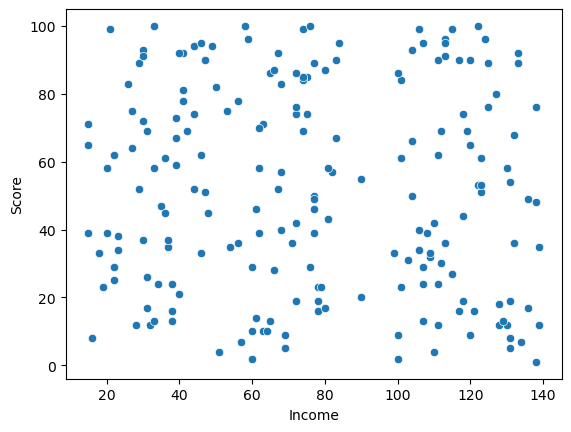

In [122]:
sns.scatterplot(x='Income', y ='Score', data=df)
plt.show()

#### 

#### for unsupervised machine learning, there is no output variable

In [123]:
X = df
# y  = nothing (unlabelled data)

## 1. K-Mean Clustering

In [124]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
    )

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

print(wcss)

[443451.375, 238971.19966212648, 159834.76355000935, 103313.76008729072, 77764.04885269172, 68385.00478231937, 59204.52989054448, 43220.51417618301, 36974.272146831994, 31774.52658671402]


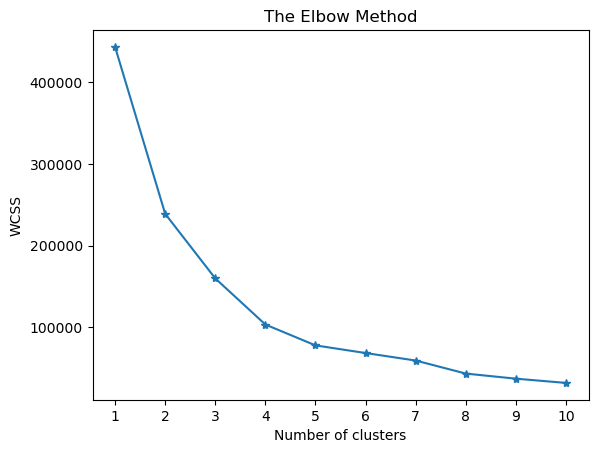

In [125]:
# using the elbow method

plt.plot(range(1, 11), wcss, marker = '*')
plt.xticks(range(1,11))
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [126]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters= 5, init = 'k-means++', random_state=True)
X['km_cluster' ] = kmeans.fit_predict(X)
X

,Income,Score,km_cluster
0,123,51,1
1,65,86,2
2,68,57,2
3,22,29,0
4,41,78,3
...,...,...,...
195,133,92,1
196,81,58,2
197,90,20,4
198,40,92,3


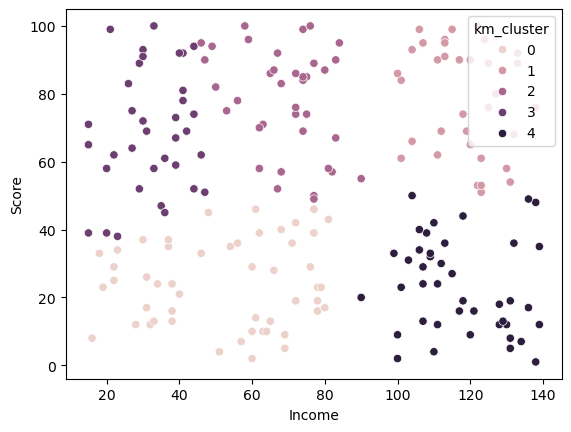

In [127]:
sns.scatterplot(x= 'Income', y = 'Score', hue = 'km_cluster', data = X)
plt.show()